In [7]:
import os

files = [f for f in os.listdir("/content")]
print(files)


['.config', 'Netflix_Titles. - netflix_titles.csv (Clean).csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv("/content/Netflix_Titles. - netflix_titles.csv (Clean).csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 8809
Columns: 12


,Show_id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_in,Description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,9/25/2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,9/24/2021,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Available,Unknown,Unknown,9/24/2021,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,9/24/2021,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_id       8809 non-null   object
 1   Type          8809 non-null   object
 2   Title         8809 non-null   object
 3   Director      8809 non-null   object
 4   Cast          8809 non-null   object
 5   Country       8809 non-null   object
 6   Date_Added    8809 non-null   object
 7   Release_Year  8809 non-null   object
 8   Rating        8809 non-null   object
 9   Duration      8809 non-null   object
 10  Listed_in     8809 non-null   object
 11  Description   8809 non-null   object
dtypes: object(12)
memory usage: 826.0+ KB


In [10]:
print("Statistical Summary:")
df.describe(include="all")

Statistical Summary:


,Show_id,Type,Title,Director,Cast,Country,Date_Added,Release_Year,Rating,Duration,Listed_in,Description
count,8809,8809,8809,8809,8809,8809,8809,8809,8809,8809,8809,8809
unique,8808,3,8807,4529,7693,747,1715,75,15,221,515,8776
top,Unknown,Movie,Unknown,Not Available,Unknown,United States,1/1/2020,2018,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,2,6131,3,2636,827,2818,110,1147,3207,1793,362,4


In [11]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Show_id', 'Type', 'Title', 'Director', 'Cast', 'Country', 'Date_Added', 'Release_Year', 'Rating', 'Duration', 'Listed_in', 'Description']


In [12]:
# Check duplicate rows
print("Exact duplicate rows:", df.duplicated().sum())

# Check duplicate Show IDs
print("Duplicate Show IDs:", df["Show_id"].duplicated().sum())

Exact duplicate rows: 1
Duplicate Show IDs: 1


In [13]:
print("Type values:")
print(df["Type"].value_counts(dropna=False))

print("\nRating values:")
print(df["Rating"].value_counts(dropna=False).head(15))

Type values:
Type
Movie      6131
TV Show    2676
Unknown       2
Name: count, dtype: int64

Rating values:
Rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        9
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [14]:
unknown_counts = (df == "Unknown").sum()

print("Unknown values by column:")
print(unknown_counts[unknown_counts > 0])

Unknown values by column:
Show_id           2
Type              2
Title             3
Cast            827
Country         833
Release_Year      2
Rating            9
Duration          2
Listed_in         2
Description       2
dtype: int64


In [15]:
df["Release_Year"] = pd.to_numeric(df["Release_Year"], errors="coerce")

print(df["Release_Year"].describe())

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: Release_Year, dtype: float64


Type
Movie      6131
TV Show    2676
Unknown       2
Name: count, dtype: int64


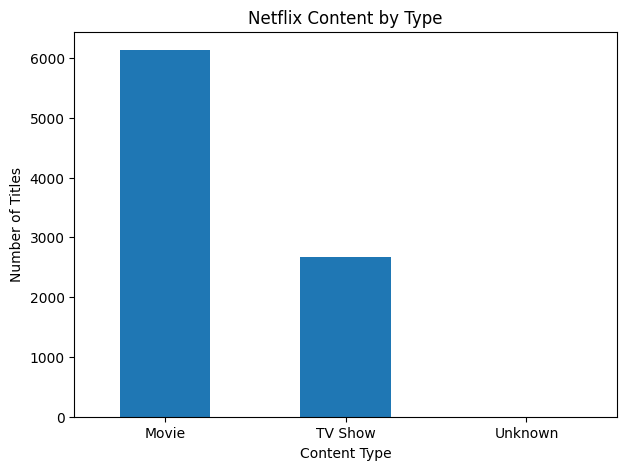

In [16]:
import matplotlib.pyplot as plt

type_counts = df["Type"].value_counts()

print(type_counts)

plt.figure(figsize=(7,5))
type_counts.plot(kind="bar")
plt.title("Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

Country
United States     2818
India              972
Unknown            833
United Kingdom     419
Japan              245
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


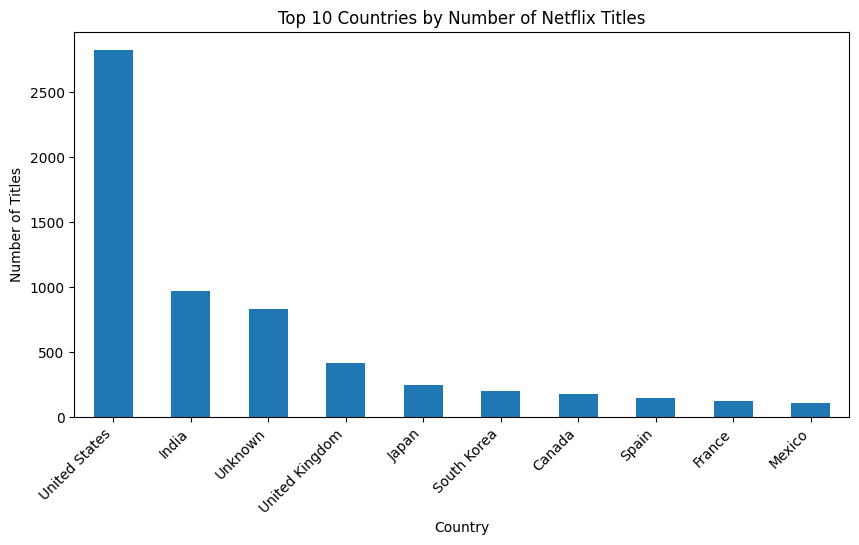

In [17]:
country_counts = df["Country"].value_counts().head(10)

print(country_counts)

plt.figure(figsize=(10,5))
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

Listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


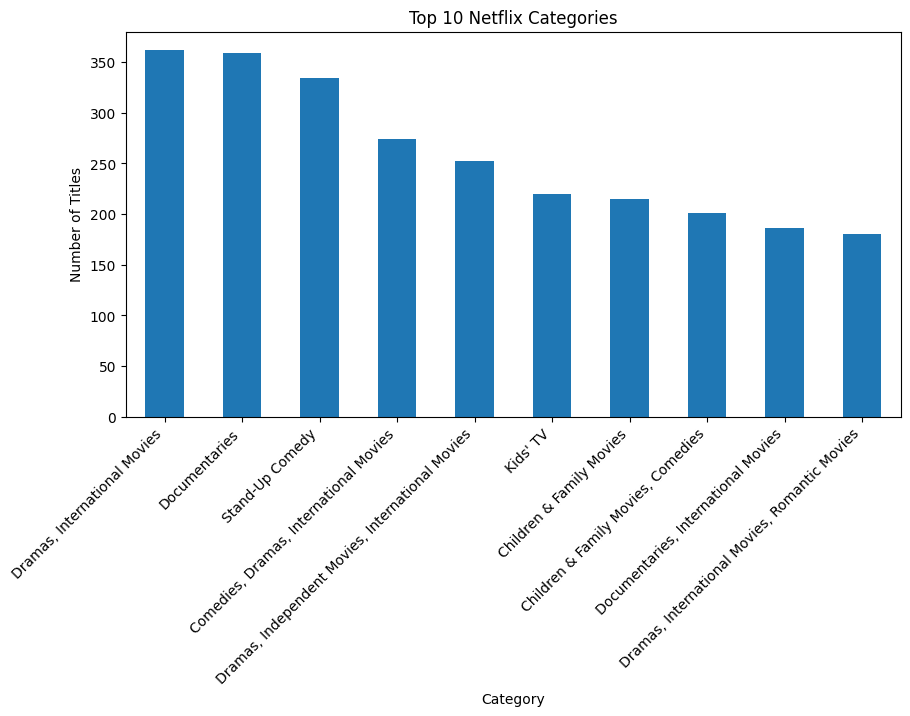

In [18]:
genre_counts = df["Listed_in"].value_counts().head(10)

print(genre_counts)

plt.figure(figsize=(10,5))
genre_counts.plot(kind="bar")
plt.title("Top 10 Netflix Categories")
plt.xlabel("Category")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

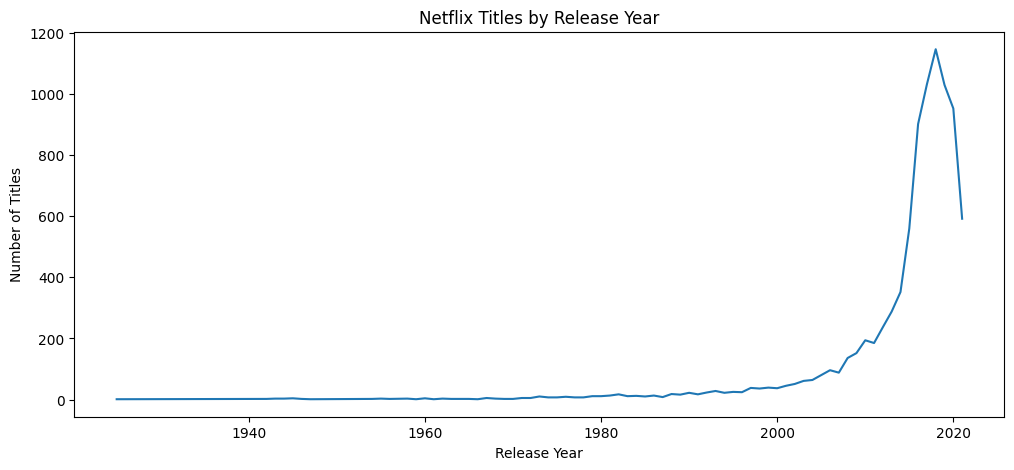

In [19]:
year_counts = df["Release_Year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

Rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


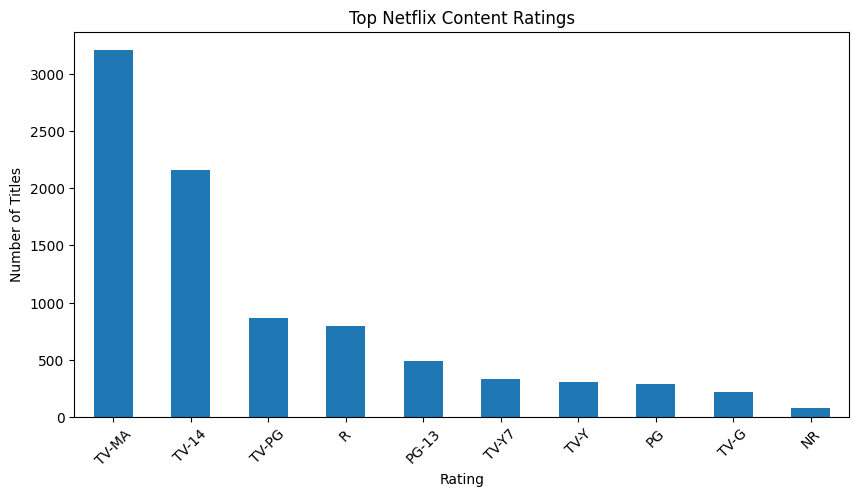

In [20]:
rating_counts = df["Rating"].value_counts().head(10)

print(rating_counts)

plt.figure(figsize=(10,5))
rating_counts.plot(kind="bar")
plt.title("Top Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [36]:
df["Duration_Minutes"] = pd.to_numeric(
    df["Duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

In [34]:
print(df["Duration_Minutes"].describe())

count    8807.000000
mean       69.848530
std        50.806431
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: Duration_Minutes, dtype: float64


In [35]:
print(
    "Average movie duration:",
    round(df["Duration_Minutes"].mean(), 2),
    "minutes"
)

Average movie duration: 69.85 minutes


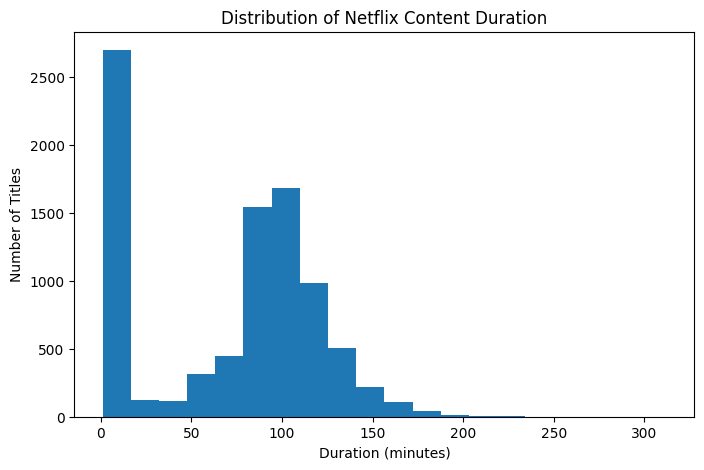

In [37]:
plt.figure(figsize=(8,5))

plt.hist(df["Duration_Minutes"].dropna(), bins=20)

plt.title("Distribution of Netflix Content Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Titles")

plt.show()

PART 12 — Important Statistics


In [38]:
print("Total Titles:", len(df))
print("Total Columns:", len(df.columns))

print("\nContent Type:")
print(df["Type"].value_counts())

print("\nTop 5 Countries:")
print(country_counts.head())

print("\nTop 5 Categories:")
print(genre_counts.head())

print("\nTop 5 Ratings:")
print(rating_counts.head())

print("\nAverage Duration:", round(df["Duration_Minutes"].mean(), 2), "minutes")

Total Titles: 8809
Total Columns: 13

Content Type:
Type
Movie      6131
TV Show    2676
Unknown       2
Name: count, dtype: int64

Top 5 Countries:
Country
United States     2818
India              972
Unknown            833
United Kingdom     419
Japan              245
Name: count, dtype: int64

Top 5 Categories:
Listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

Top 5 Ratings:
Rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Average Duration: 69.85 minutes
